# 06: The Contractors' Economics

**Business question**: Three of Malaysia's largest construction groups, Sunway Construction, Gamuda, and IJM Corporation, are all building data centres. None of them report a clean "data centre segment" the way YTL Power does. How exposed is each one really, and is this genuinely a higher-margin business for them, as commonly assumed?

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
contracts = pd.read_sql_query("SELECT * FROM contractor_contracts ORDER BY company, date_announced", conn)
orderbooks = pd.read_sql_query("SELECT * FROM contractor_orderbooks", conn)
conn.close()
contracts_summary = contracts.groupby('company')['contract_value_rm_m'].agg(['count', 'sum']).rename(columns={'count': 'contracts_found', 'sum': 'total_rm_m'})
contracts_summary

,contracts_found,total_rm_m
company,,
Gamuda,3,5173.00
IJM Corporation,3,2931.91
Sunway Construction,5,4591.60


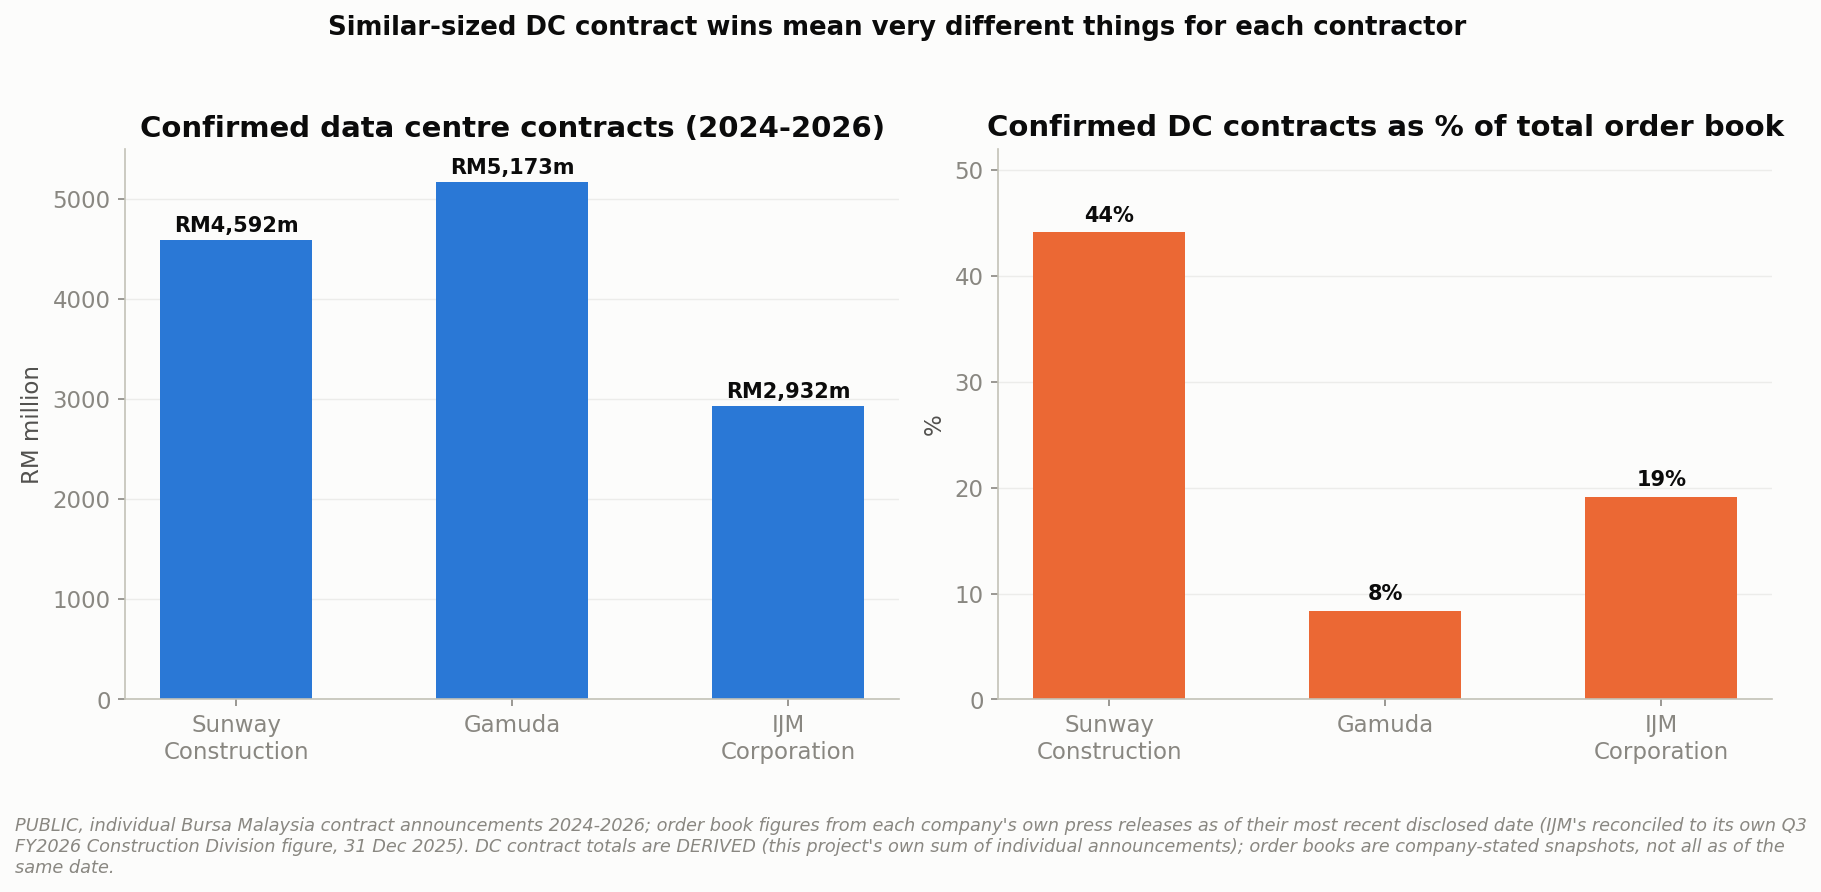

In [2]:
from IPython.display import Image
Image(filename='../outputs/figures/06_contractor_economics.png')

## Why this notebook's numbers are hand-built, not pulled from one table

Unlike YTL Power (Notebook 5), none of these three contractors reports a standalone, recurring "data centre" segment. Every figure in this notebook is aggregated by this project from individual Bursa Malaysia contract-win announcements, so the totals above are a **floor**, the confirmed contracts this project could find and verify, not a company-published total. **[DERIVED, this project's own aggregation of individually PUBLIC Bursa announcements]**

Sunway Construction Group's confirmed data centre contracts (five Johor and Selangor jobs, 2025-2026) total **RM4.59 billion**, against a company-disclosed order book of **RM10.4 billion** (5 August 2026), roughly 44% by this project's conservative count. Sunway Construction itself separately disclosed a **tender book of RM13.5 billion (July 2026), of which analysts at The Star estimated approximately 90% is data-centre-related**, a larger, less certain figure that includes bids not yet won, not the same base as the awarded-contract total above. **[PUBLIC contract/order-book figures; the "90% of tender book" figure is analyst commentary, not company-published]**

Gamuda's three confirmed data centre contracts (all at Port Dickson and Elmina) total **RM5.17 billion**, against a much larger and more geographically diversified order book that reached **RM61.6 billion by late September 2026** (boosted by a large non-data-centre Australian infrastructure win), putting Gamuda's confirmed data centre exposure at roughly 8% of its total book, a real and meaningful business line, but a small share of a much larger, more diversified company than Sunway Construction. **[PUBLIC contract figures; order-book percentage DERIVED by this project]**

IJM Corporation's three confirmed contracts total **RM2.93 billion**. Its order-book figures, which an earlier version of this notebook flagged as conflicting and unreconciled, turn out to be a real, consistent growth trend once traced to IJM's own primary press releases rather than secondary aggregation: **RM7.6 billion (31 March 2025, FY2025 year-end, construction order book)**, rising to **RM12.9 billion (30 June 2025, Group total)**, largely explained by a **RM3.5 billion addition from IJM's 50% acquisition of UK-based JRL Group**, completed just after FY2025 year-end, plus new contract wins named in the same release, and further to **RM15.3 billion (31 December 2025, Construction Division order book, including its share of joint ventures and associates)**. Against that most recent, most comparably-scoped figure, IJM's confirmed data centre contracts are about **19%** of its construction order book. Two smaller secondary figures found earlier (RM9.2bn, RM9bn) appear to be simplified "base plus one headline contract" calculations that missed the JRL acquisition and IJM's other simultaneous wins; this notebook uses IJM's own reconciled figures instead. **[PUBLIC, IJM Corporation's own press releases, cited via independent press pickup (Bernama, The Edge, BusinessToday) since IJM's own website terms restrict content reproduction, the same pattern already found for TNB, JLL, and Bank Negara Malaysia elsewhere in this project; the 19% share calculation is DERIVED by this project]**

## The margin narrative doesn't hold up as cleanly as assumed

A common assumption going into this notebook was that data centre construction, with its specialised mechanical, electrical, and plumbing (MEP) and cooling requirements, commands meaningfully higher margins than ordinary construction work. The evidence found does not support that as a general rule. Analysts estimated Sunway Construction's roughly RM1.75 billion Selangor hyperscale job would earn around a **6% net margin, "in line with SunCon's core net margins,"** not distinctly above them, though the company's own guided PBT range of 5-8% suggests data centre work lands at the **upper end** of that range rather than dramatically above it. **[DERIVED, analyst estimate via The Edge Malaysia and BusinessToday reporting, not a direct company margin disclosure]** Separately, one analyst house assumed a 10% pretax margin for a different shared Gamuda/IJM/Sunway Construction pipeline of Selangor data centre jobs, an assumption for a different set of contracts, not directly comparable to the 6% figure above, and itself an analyst estimate rather than a company disclosure. Where this project could find company guidance rather than analyst assumption, data centre construction looks like solid, dependable work at or slightly above a contractor's normal margins, not the distinctly higher-margin business it is sometimes assumed to be. **[Disclosed finding, contradicts a common but unverified assumption]**

## The rare cases where a real client is actually named

Almost every contract found in this research anonymises its client as "a US MNC" or "an international hyperscaler," standard practice for these announcements. Two exceptions are worth featuring: IJM's RM873.9 million Elmina Business Park contract (October 2024) names its client directly as **Pearl Computing Malaysia Sdn Bhd, a subsidiary of Raiden APAC Pte Ltd**, and IJM's RM658.01 million second Elmina package (April 2026) was awarded via a letter of award from **Sime Darby Property (EBP Asset II) Sdn Bhd**, meaning the direct commercial relationship in that case runs through a property developer acting as an intermediary landlord/developer, not directly with the eventual data centre operator. **[PUBLIC, Bursa filings via The Edge Malaysia]** This is a useful, concrete data point for Notebook 9's value-chain question: at least one real deal in this dataset shows a developer, not the hyperscaler itself, as the direct contracting party.

## Explain It Simply

Three of Malaysia's biggest construction companies are all building data centres, but none of them publish one clean "here's our data centre business" number the way YTL Power does; you have to add up individual construction contracts one by one to see how exposed each one really is. Once added up, the picture is quite different for each: Sunway Construction is the most concentrated, with data centre work making up a huge and growing share of everything it's building; Gamuda is doing serious data centre work too, but it's a small slice of a much bigger, more spread-out business; and IJM sits somewhere in between. A common belief going in, that building data centres is a distinctly more profitable kind of construction work, turned out not to be clearly true: the actual numbers found suggest it earns roughly normal-to-slightly-better construction margins, not an exceptional premium.

## Glossary

- **Order book**: the total value of contracts a construction company has already been awarded and has yet to complete.
- **Tender book**: the total value of contracts a company has bid on but not necessarily won yet, a larger and less certain figure than the order book.
- **MEP (Mechanical, Electrical, and Plumbing)**: the specialised building systems, especially cooling and power distribution, that make data centre construction more technically demanding than a standard warehouse or office building.
- **Net margin / PBT margin**: profit as a percentage of contract or company revenue, used here to compare how profitable different kinds of construction work are.

## Why Is This Happening?

**Why doesn't data centre construction earn the outsized margin premium commonly assumed?** Construction margins are set primarily by competitive bidding, and as data centre construction has matured from a novel, specialised niche into a large, well-understood category with multiple qualified contractors (exactly the three companies in this notebook, plus others), competition for these jobs has intensified in step with the specialised skills required to win them. A genuinely scarce capability commands a premium only while it stays scarce; once enough contractors can competently deliver hyperscale MEP and cooling work, as appears to be the case in Malaysia today, pricing competition erodes much of that premium even as demand keeps growing, which is consistent with this notebook's finding that guided margins sit at the upper end of normal ranges rather than clearly above them.

---
**Sources**: Individual Bursa Malaysia contract announcements, 2024-2026, for Sunway Construction Group, Gamuda Berhad, and IJM Corporation (via company press releases and The Edge Malaysia, BusinessToday, and The Star reporting); company quarterly results and investor presentations for order-book figures. Individual contract values and order-book snapshots are **PUBLIC**; the per-company DC-contract totals, order-book share percentages, and margin-comparison framing are this project's own, classified **DERIVED**; the "~90% of tender book" and "10% pretax margin" figures are explicitly attributed as analyst estimates, not company disclosures.